# <a id='toc1_'></a>[T23 State Space Control - Part 1](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [T23 State Space Control - Part 1](#toc1_)    
  - [FSFB using LQR](#toc1_1_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [ ]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

bm.setup_environment()
cm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from scipy.optimize import fsolve


In [105]:
colors = bm.get_colors()
j = complex(0,1)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText
import sympy as sp

import control as ct
import control.matlab as cmat

from scipy.optimize import minimize
from scipy.signal import butter,bessel

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

## <a id='toc1_1_'></a>[FSFB using LQR](#toc0_)

In [106]:
def compute_Nbar(G,k0):
    Nbar0 = 1.0/np.dot(-G.C,np.dot(np.linalg.inv(G.A-np.dot(G.B,k0)),G.B)).item()
    return Nbar0   

In [107]:
def FSFB_lqr(G,R,file_name='temp',w = np.logspace(-1,2,400),Tmax=1):
    nx = G.A.shape[0]
    t = np.linspace(0,Tmax,1000)
    
    k0,_,_ = ct.lqr(G.A,G.B,G.C.reshape(nx,1)*G.C,R)
    k0 = np.asarray(k0)
    k1,_,_ = ct.lqr(G.A,G.B,G.C.reshape(nx,1)*G.C,10*R)
    k1 = np.asarray(k1)
    #
    # For state space for G_c(s)
    #
    # find the feedforward gains
    Nbar0 = compute_Nbar(G,k0)
    Nbar1 = compute_Nbar(G,k1)

    sys0 = ct.ss(G.A-G.B @ k0,G.B*Nbar0,G.C,G.D)
    sys1 = ct.ss(G.A-G.B @ k1,G.B*Nbar1,G.C,G.D)

    print(f"Nbar0 = {Nbar0:.3f}")
    print(f"Nbar1 = {Nbar1:.3f}")
    cm.pretty_row_print("k0 = ",k0,bracket="[]")
    cm.pretty_row_print("k1 = ",k1,bracket="[]")

    if nx < 4:
        w = np.logspace(-1,2,400)
    else:
        w = np.logspace(-1,2,400)
    Gf = G(w*j)
    sys0f = sys0(j*w)
    sys1f = sys1(j*w)

    t = np.arange(0,Tmax,.01)    
    y0,t0 = cmat.step(sys0,T=t)
    y1,t1 = cmat.step(sys1,T=t)

    _, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
    ax.plot(t0,y0,'b-',label=r'$y_0$'+f" {R =:5.3f}")
    ax.plot(t1,y1,'g--',label=r'$y_1$'+f" {10*R =:5.3f}")
    plt.legend()
    plt.text(max(t0)/2,.8,rf"$\bar N_0$ = {Nbar0:3.1f}", fontsize=16)
    if nx < 4:
        plt.text(max(t0)/2, 0.3,'k = ['+', '.join('{:6.2f}'.format(i) for i in np.squeeze(k0))+']', fontsize=14)
    plt.ylabel("Response")
    plt.xlabel("Time")
    plt.savefig("figs/FSFB"+file_name+"_0.pdf", dpi=600)
    plt.show()

    ymax = max(np.max(np.abs(Gf)),np.max(np.abs(sys0f)),np.max(np.abs(sys1f)))
    ymax = 10**np.ceil(np.log10(1.5*ymax))
    fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150,constrained_layout = True)
    ax[0].loglog(w,np.abs(Gf),'b',label=r'G')
    ax[1].semilogx(w,np.unwrap(np.angle(Gf))*cm.r2d,'b',label=r'G')
    ax[0].loglog(w,np.abs(sys0f),'g',label=r'sys0'+f" {R =:5.3f}")
    ax[1].semilogx(w,np.unwrap(np.angle(sys0f))*cm.r2d,'g',label=r'sys0'+f" {R =:5.3f}")
    ax[0].loglog(w,np.abs(sys1f),'r',label=r'sys1'+f" {10*R =:5.3f}")
    ax[1].semilogx(w,np.unwrap(np.angle(sys1f))*cm.r2d,'r',label=r'sys1'+f" {10*R =:5.3f}")
    ax[1].set_xlabel('Freq [r/s]')
    ax[0].set_ylabel('Mag')
    ax[1].set_ylabel('Phase (degs)')
    ax[0].grid(True, which="both", ls="-",color='0.65')
    ax[1].grid(True, which="both", ls="-",color='0.65')
    ax[0].axhline(y=1,c='k',ls='--')
    ax[1].axhline(y=-180,c='k',ls='--')
    ax[0].legend()
    ax[0].set_ylim(1e-3,ymax)
    plt.savefig("figs/FSFB"+file_name+"_1.pdf", dpi=600)
    plt.show()

    return k0

Nbar0 = 10.050
Nbar1 = 3.317


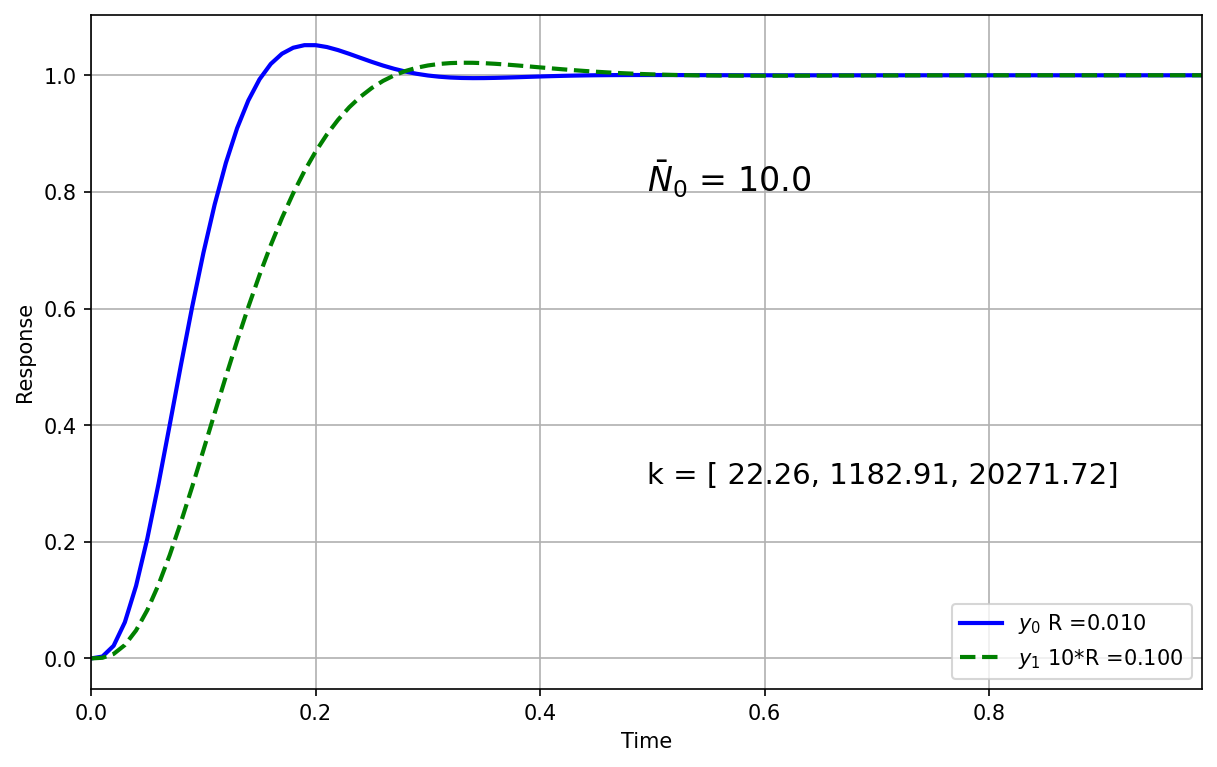

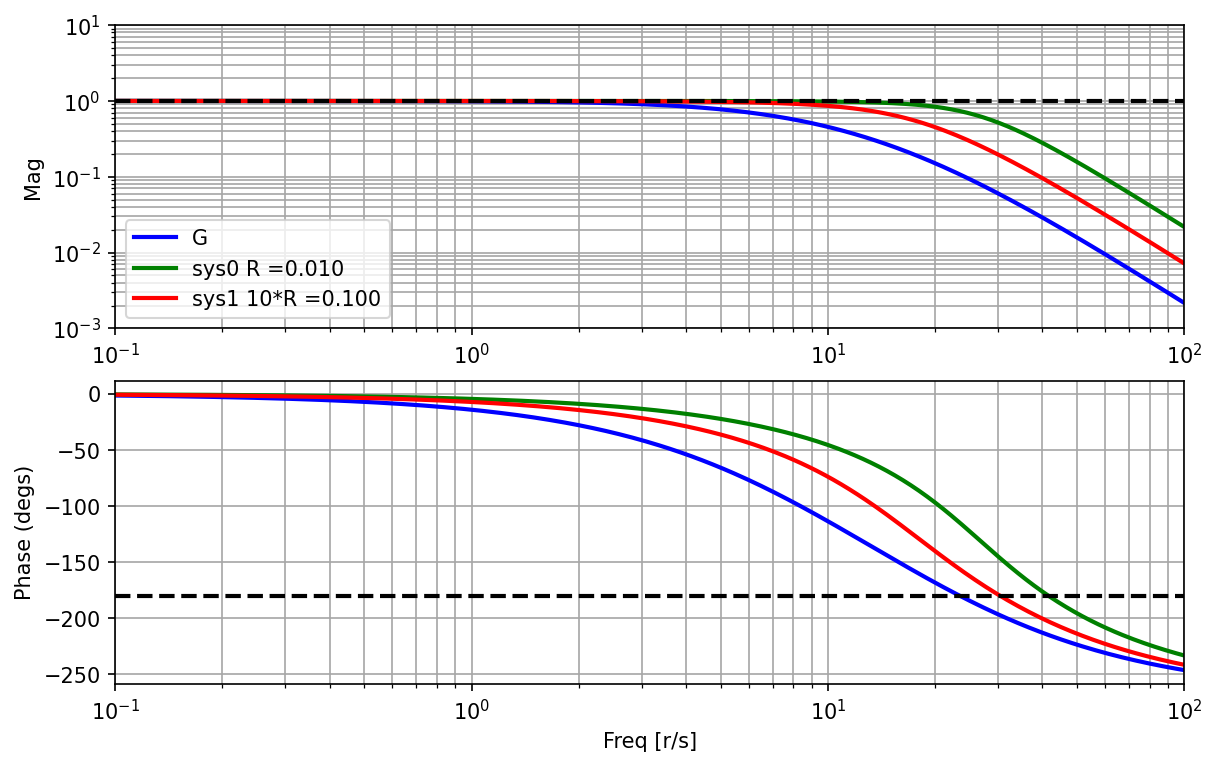

In [108]:
G1 = ct.ss(ct.tf(8*14*20,np.convolve([1, 8],np.convolve([1, 14],[1, 20]))))
R = 1e-2
file_name = 'examp1'
K1 = FSFB_lqr(G1,R,file_name=file_name)

Nbar0 = 3.162
Nbar1 = 1.000


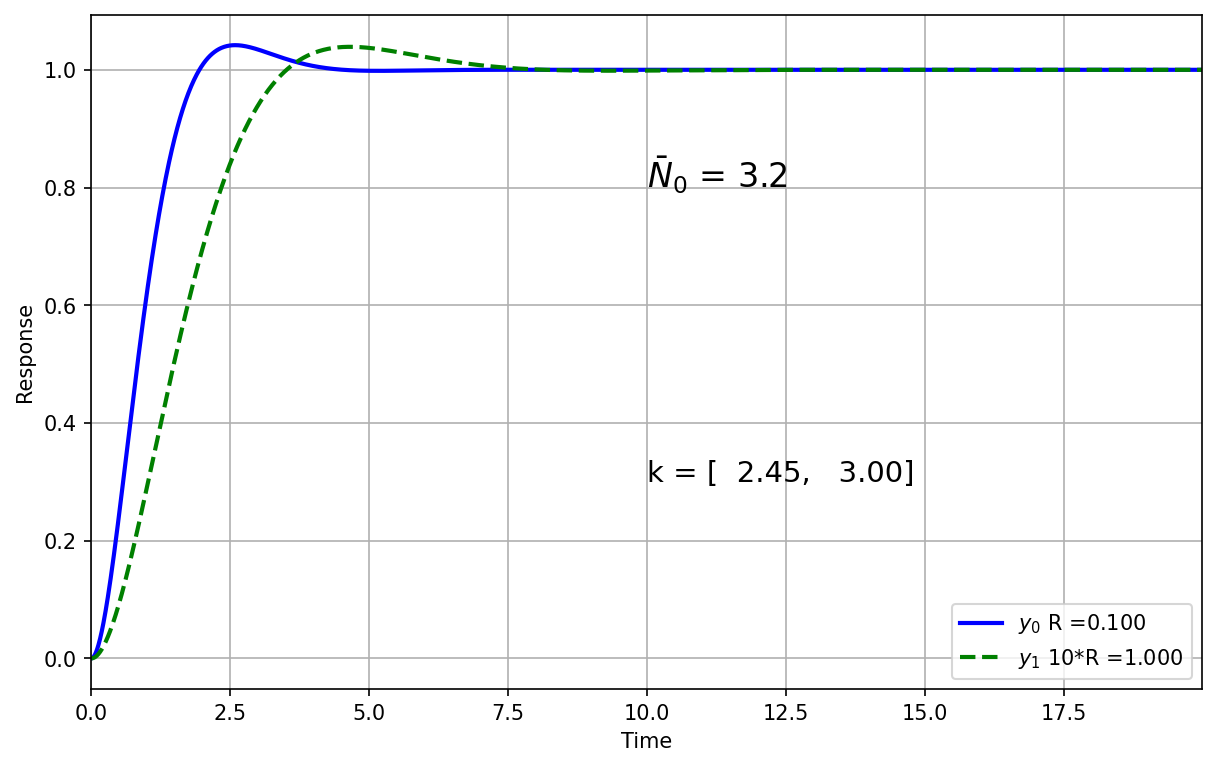

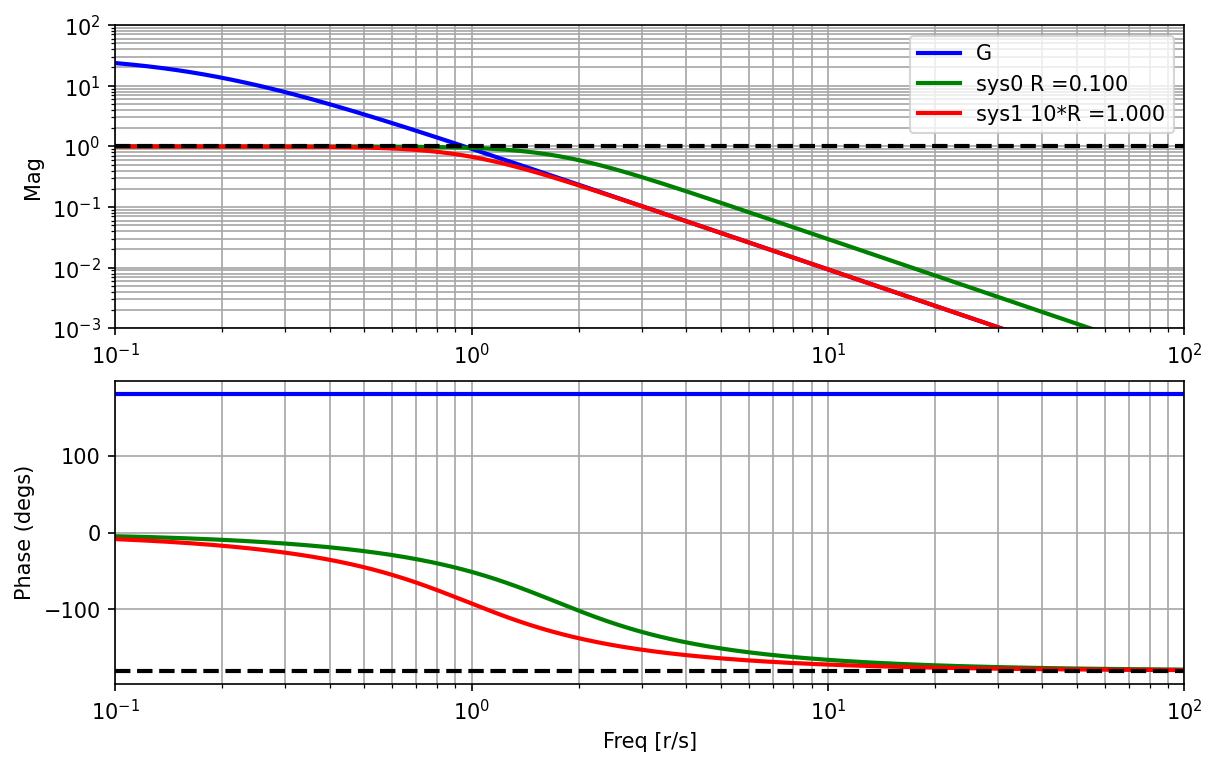

In [109]:
G2 = ct.ss(ct.tf(0.94,(1,0,-0.0297)))
R = 0.1
file_name = 'examp2'
K2 = FSFB_lqr(G2,R,file_name=file_name,Tmax=20)

Nbar0 = 10.050
Nbar1 = 3.317


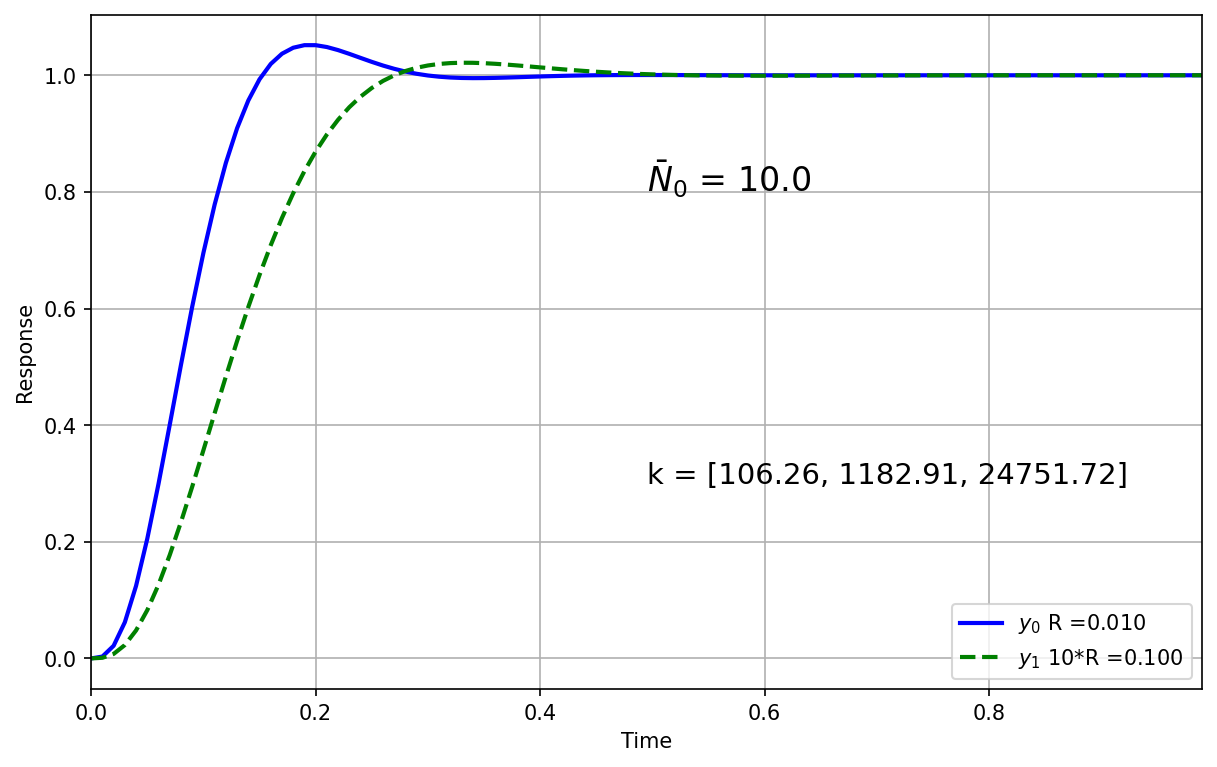

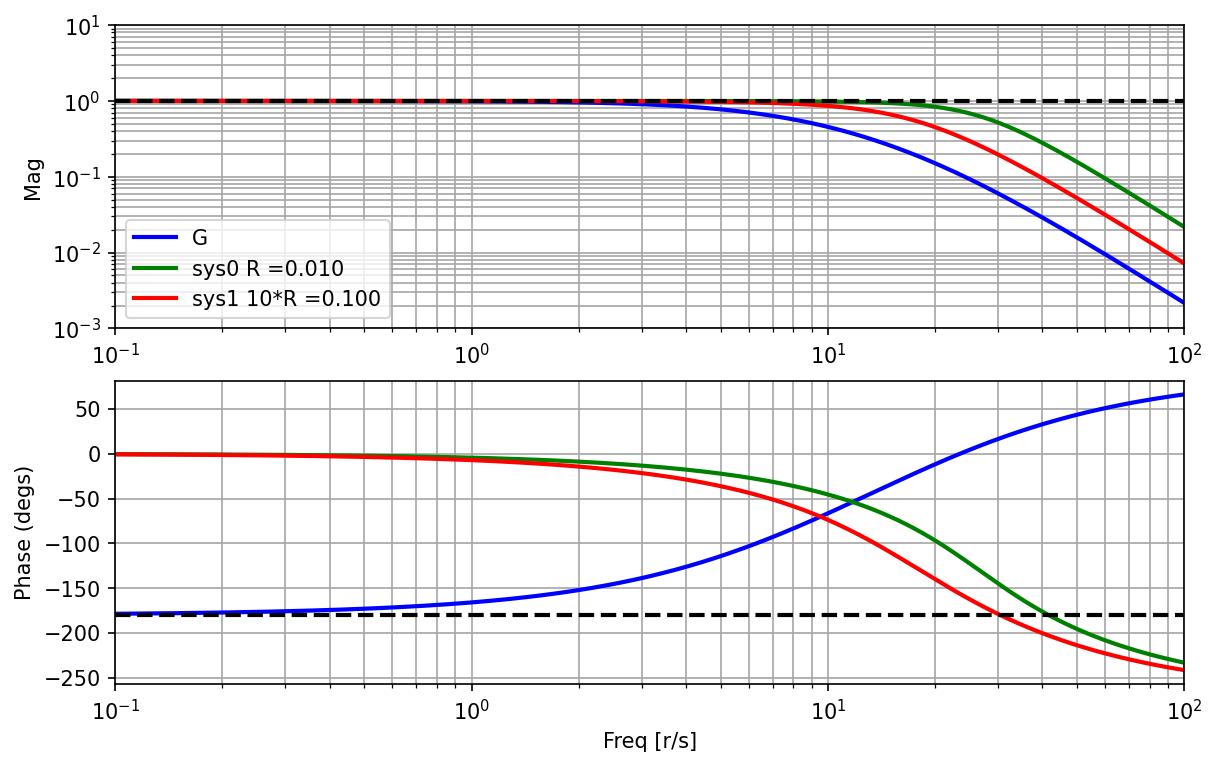

In [110]:
G3 = ct.ss(ct.tf(8*14*20,np.convolve([1, -8],np.convolve([1, -14],[1, -20]))))
R = 1e-2
file_name = 'examp3'
K3 = FSFB_lqr(G3,R,file_name=file_name)


Nbar0 = -4.359
Nbar1 = -3.162


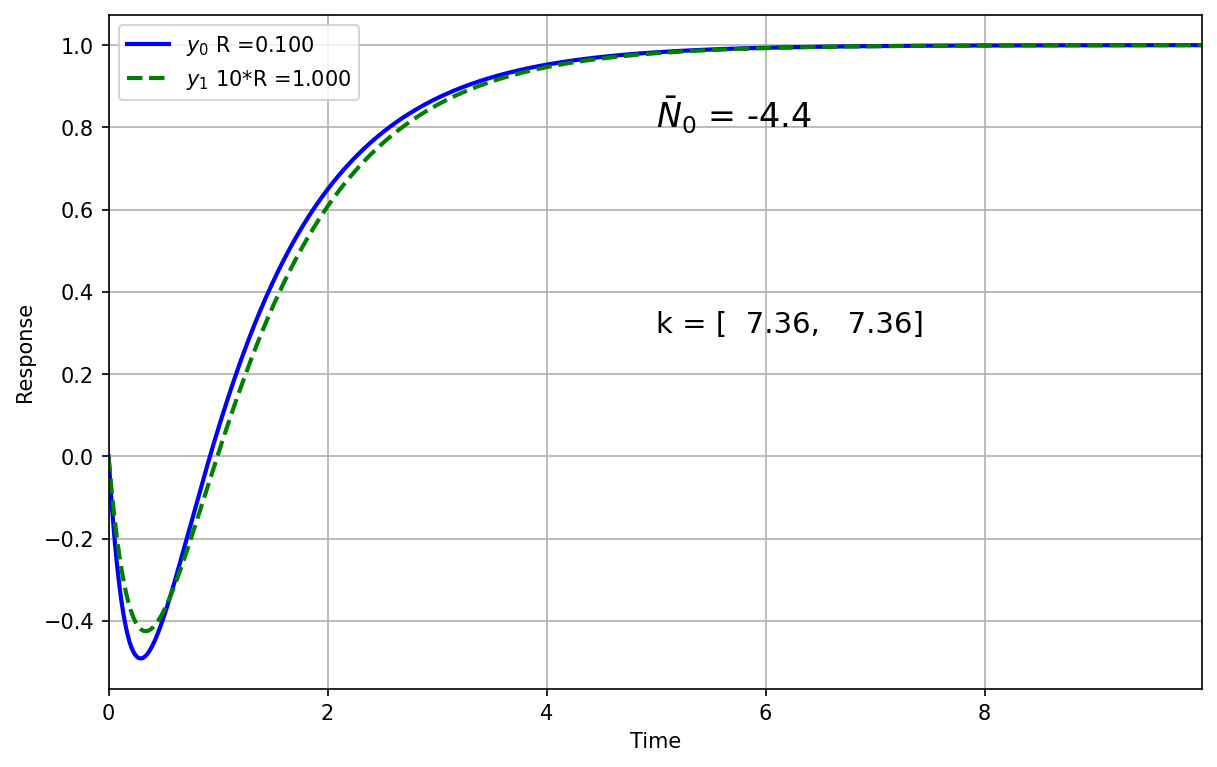

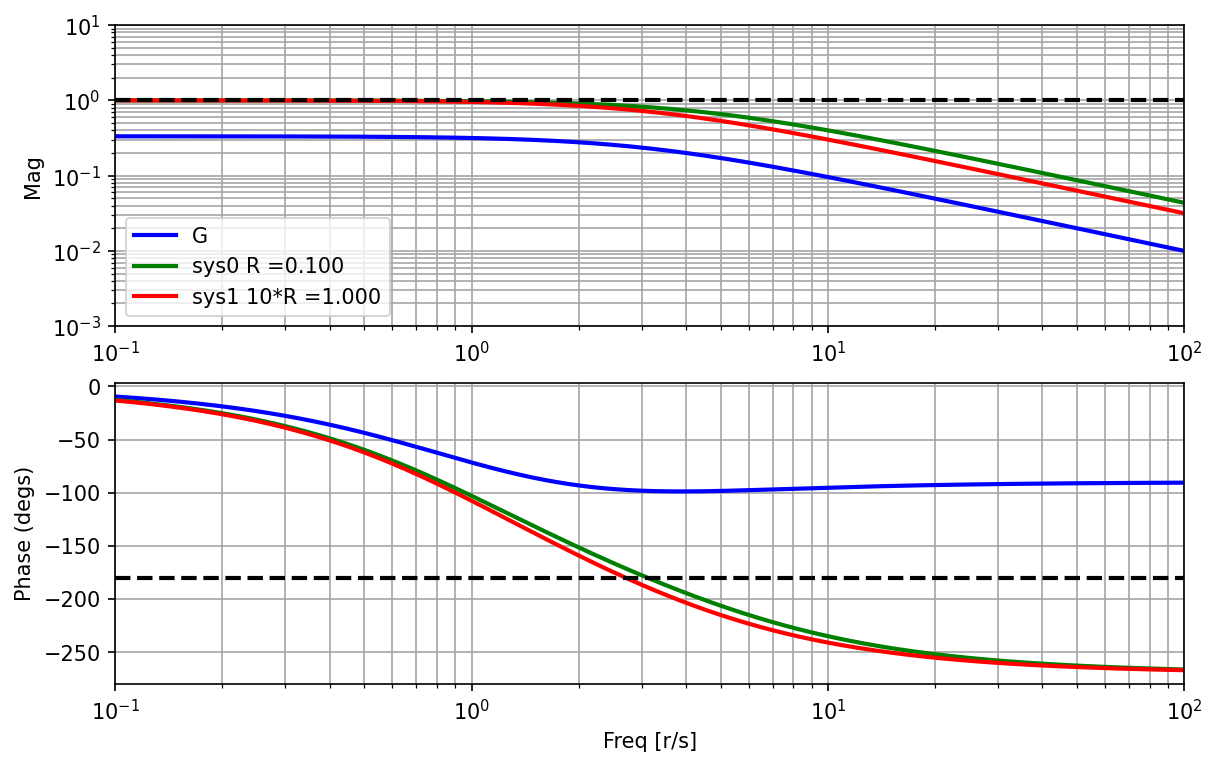

In [111]:
G4 = ct.ss(ct.tf((1,-1),(1,-2,-3)))
R = 0.1
file_name = 'examp4'
K4 = FSFB_lqr(G4,R,file_name=file_name,Tmax=10)

Nbar0 = 3.162
Nbar1 = 1.000


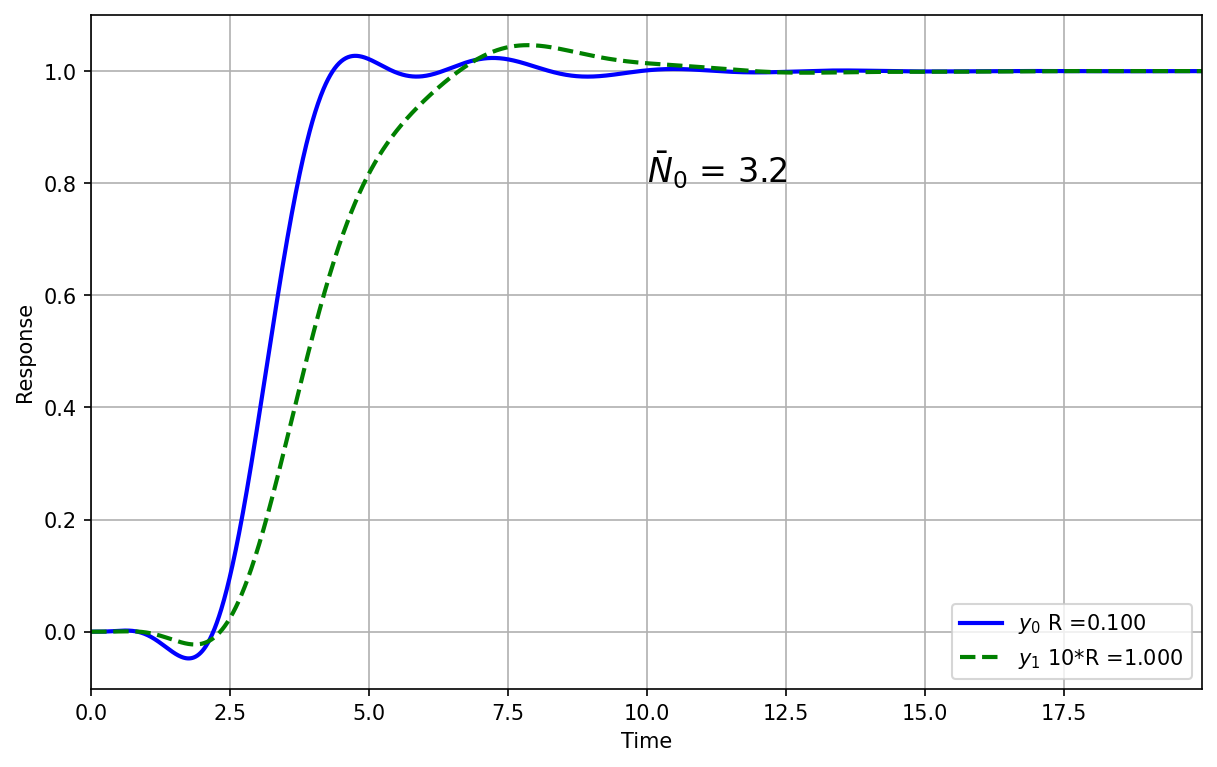

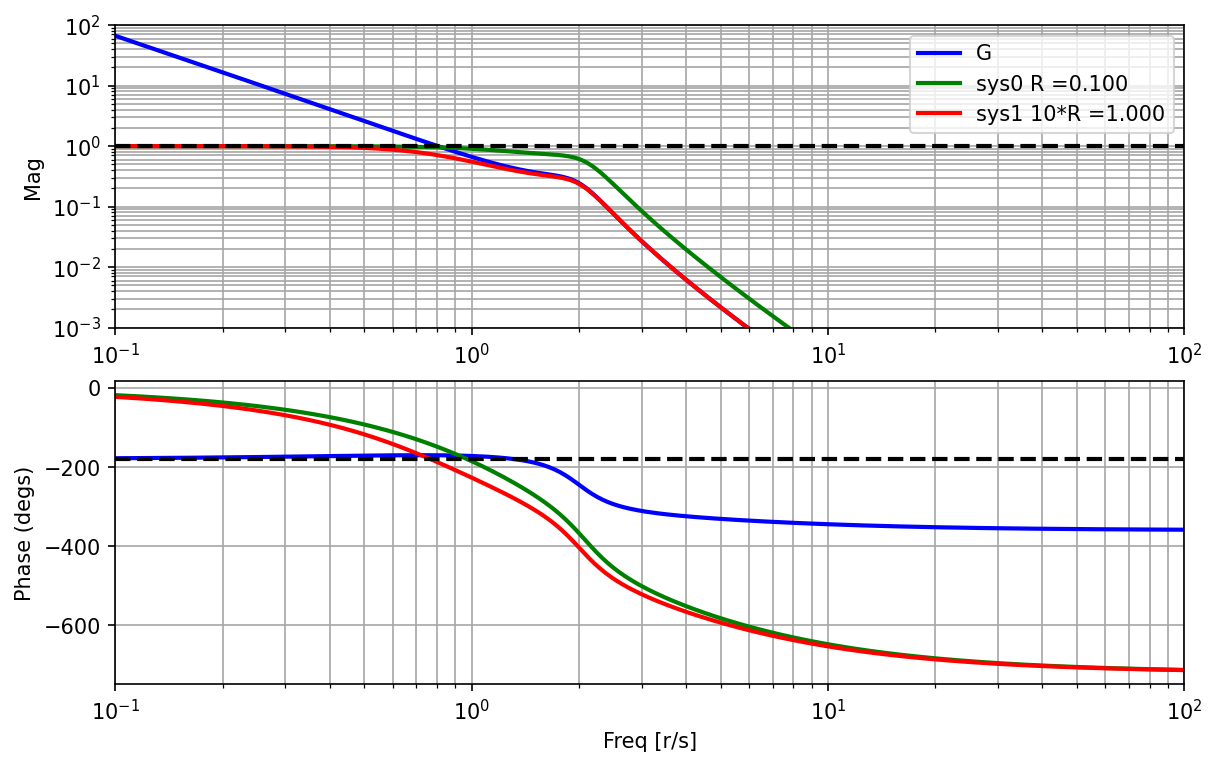

In [112]:
G5 = ct.ss(ct.tf((1,-6,8),np.convolve([1,0,0],np.convolve([1,.8,4],[1,-4,3]))))
R = 0.1
file_name = 'examp5'
K5 = FSFB_lqr(G5,R,file_name=file_name,Tmax=20)